# Data Normalization

In [1]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer, QuantileTransformer


In [2]:
# make a ranodm non mormal data
data= np.random.exponential(scale=2, size=1000)
data= pd.DataFrame(data, columns=["values"])
data.head()

,values
0,0.463159
1,0.709514
2,1.428874
3,1.842117
4,1.143727


<Axes: xlabel='values', ylabel='Count'>

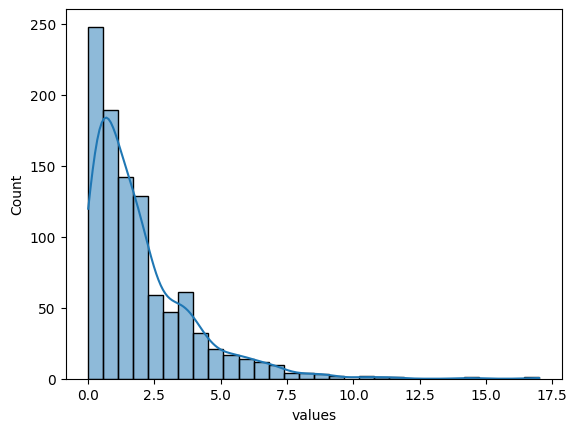

In [3]:
# make a histplot of this data
sns.histplot(data=data, x='values', bins=30, kde=True)

In [6]:
# Box-Cox and Yeo-Johnson transformations
pt_box_cox = PowerTransformer(method='box-cox', standardize=False)
pt_yeo_johnson = PowerTransformer(method='yeo-johnson', standardize=False)
qt_normal = QuantileTransformer(output_distribution='normal')

df = data.copy()

# boxcox ky lye +1 add krna lazmi hai
df['Box_Cox'] = pt_box_cox.fit_transform(df[['values']] + 1)
df['Yeo_Johnson'] = pt_yeo_johnson.fit_transform(df[['values']])
df['Quantile'] = qt_normal.fit_transform(df[['values']])

df.head(10)

,values,Box_Cox,Yeo_Johnson,Quantile
0,0.463159,0.355302,0.355302,-0.819656
1,0.709514,0.486918,0.486918,-0.529301
2,1.428874,0.757839,0.757839,0.051460
3,1.842117,0.868221,0.868221,0.288750
4,1.143727,0.665468,0.665468,-0.154930
5,1.390749,0.746368,0.746368,0.021329
6,0.112526,0.104581,0.104581,-1.562721
7,0.393208,0.312294,0.312294,-0.910873
8,0.019264,0.019014,0.019014,-2.325972
9,0.344386,0.280489,0.280489,-1.006211


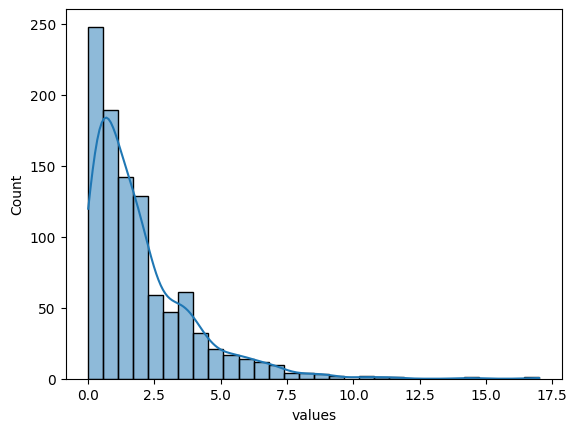

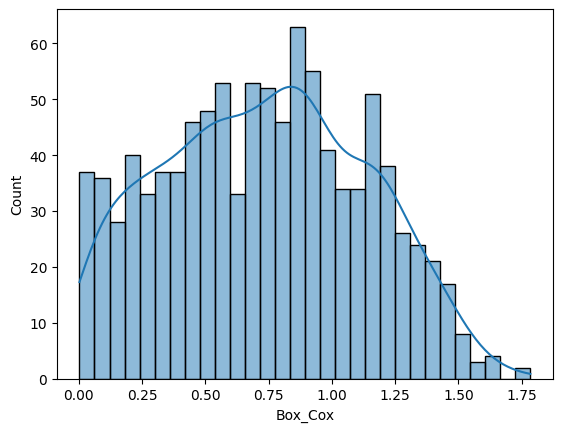

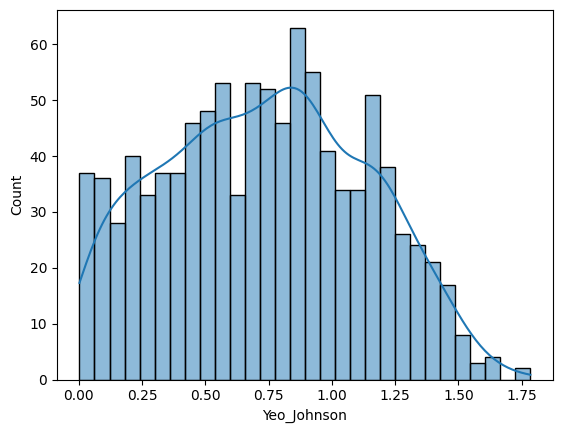

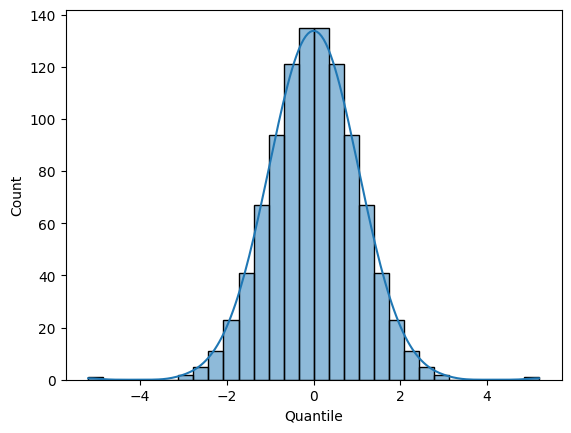

In [7]:
# now make a histogram of the transformed data
for col in ['values', 'Box_Cox', 'Yeo_Johnson', 'Quantile']:
    sns.histplot(data=df, bins=30, x=col, kde=True)
    plt.show()